Objects in scene: ['no-name-5', 'no-name-6', 'Floor']
Radio Materials in scene: ['itu_glass', 'itu_concrete', 'itu_very_dry_ground']


<Figure size 800x1000 with 0 Axes>

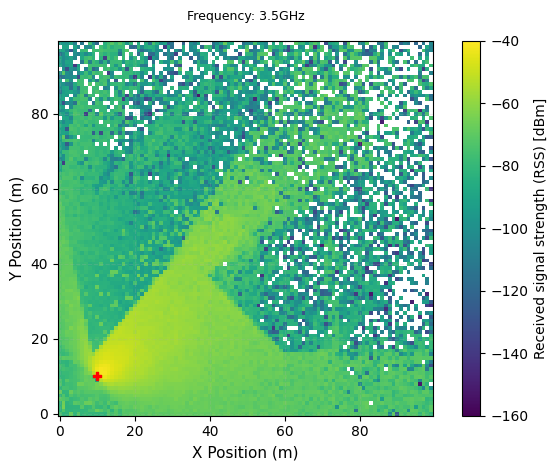

Total paths found: 462
Total RSS Power in Rx (W): 9.02672320918973e-12 W
Total RSS Power in Rx (dBm): -80.44469874319311 dBm


In [5]:
# Import libraries
import numpy as np
from sionna.rt import load_scene, ITURadioMaterial, Transmitter, Receiver, PlanarArray, RadioMapSolver, PathSolver
import matplotlib.pyplot as plt
import pandas as pd

# Import scene from blender mitsuba export (.xml)
# scene = load_scene("blender-assets/empty-room/emptyroom-100x100m.xml")
scene = load_scene("blender-assets/obstacle-room/obstacleroom-100x100m.xml")

# Check objects in the scene
print(f"Objects in scene: {list(scene.objects.keys())}")
# Check current material in the scene
print(f"Radio Materials in scene: {list(scene.radio_materials.keys())}")

# Add array for both Tx and Rx to scene
scene.tx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

# Add frequency to scene
carrier_freq = 3.5e9 # In Hz
scene.frequency = carrier_freq

# Deploy Tx and Rx location
tx = Transmitter("tx", [-40, -40, 1.5], [0, 0,0], power_dbm=10)
rx = Receiver("rx", [40, 40, 1.5], [0, 0, 0])

# Point Tx and Rx towards each other
tx.look_at(rx.position)
rx.look_at(tx.position)

# Add Tx and Rx to the scene
scene.add(tx)
scene.add(rx)

# Plot 2D Radio Map
rm_solver = RadioMapSolver()

rm = rm_solver(
    scene,
    max_depth=10,
    samples_per_tx=10**7,
    cell_size=(1, 1),
    center=[0, 0, 0],
    size=[100, 100],
    orientation=[0, 0, 0]
)

plt.figure(figsize=(8, 10))

# Show radio map
rm.show(metric="rss")

plt.title(
    f"Frequency: {carrier_freq/1e9}GHz",
    fontsize=9,
    pad=15
)
plt.xlabel("X Position (m)", fontsize=11)
plt.ylabel("Y Position (m)", fontsize=11)
plt.clim(-160, -40)
plt.grid(
    alpha=0.2,
    linestyle="--"
)
plt.tight_layout()
plt.show()

# Study multipath property
# Run path solver
p_solver = PathSolver()

paths = p_solver(
    scene,
    max_depth=10,
    samples_per_src=10**6
)

# Extract path a_a_a_a_a_a_coefficients [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
a = paths.a
if isinstance(a, tuple):
    a = a[0]
a = a.numpy()
# print("a shape:", a.shape)

# Extract path delays [num_rx, num_tx, num_paths]
tau = paths.tau
if isinstance(tau, tuple):
    tau = tau[0]
tau = tau.numpy()
# print("tau shape:", tau.shape)

# Extract valid path mask flage [num_rx, num_tx, num_paths]
valid = paths.valid
if isinstance(valid, tuple):
    valid = valid[0]
valid = valid.numpy()
# print("valid shape:", valid.shape)

# Check total number of paths
num_paths = a.shape[-1]
print(f"Total paths found: {num_paths}")

# Combine multipath properties into dataframe
path_data = []

for i in range(num_paths):

    # Skip invalid paths
    if not valid[0, 0, i]:
        continue
    
    # Extract paths coefficients  
    a_coeff = a[0, 0, 0, 0, i]

    # Calculate path channel gain
    channel_gain_linear = np.abs(a_coeff)**2 # Combine I (real - phase) + Q (imaginary - amplitude)
    channel_gain_db = 10 * np.log10(channel_gain_linear)

    # Calculate RSS at receiver
    rss_power_dbm = (channel_gain_db + tx.power_dbm)
    rss_power_w = 10**((rss_power_dbm - 30)/10)
    
    # Convert numpy scalar type to normal float variables
    rss_power_dbm = rss_power_dbm.item()
    rss_power_w = rss_power_w.item()

    # Extract delay coefficients
    delay_s = tau[0, 0, i]

    # Calculate delay distance (Free space)
    distance_m = delay_s * 3e8

    # Generate list like a dataframe with column name
    path_data.append({
        "path_id": i,
        "delay_s": delay_s,
        "distance_m": distance_m,
        "real_coeff": np.real(a_coeff),
        "imag_coeff": np.imag(a_coeff),
        "magnitude": np.abs(a_coeff),
        "phase_rad": np.angle(a_coeff),
        "channel_gain_db": channel_gain_db,
        "rss_power_w": rss_power_w,
        "rss_power_dbm": rss_power_dbm
    })

# Put array in Dataframe
df_paths = pd.DataFrame(path_data)

# Calculate total RSS in receivers
total_rss_power_w = df_paths["rss_power_w"].sum()
total_rss_power_dbm = 10 * np.log10(total_rss_power_w) + 30

print(f"Total RSS Power in Rx (W): {total_rss_power_w} W")
print(f"Total RSS Power in Rx (dBm): {total_rss_power_dbm} dBm")

# Export CSV
df_paths.to_csv("multipath_paths_list.csv", index=False)

# Optional - Scene Preview (Radio Map)
rm_solver = RadioMapSolver()

rm = rm_solver(
        scene,
        max_depth=10, # Number of maximum interation allowed per paths
        samples_per_tx=10**7, # Number of rays launch in transmitter
        cell_size=(1, 1),
        center=[0, 0, 0],
        size=[100, 100], # Size of area to simulate (meter)
        orientation=[0, 0, 0]
    )

scene.preview(
    radio_map=rm,

    rm_metric="rss",
    rm_db_scale=True,

    rm_vmax = -40,
    rm_vmin = -160,

    show_devices=True,
    show_orientations=True,

    point_picker=False
)

# Optional - Scene Preview (Paths)
# p_solver = PathSolver()

# paths = p_solver(
#     scene,
#     max_depth=10,
#     samples_per_src=10**6
# )

# scene.preview(
#     paths=paths,

#     show_devices=True,
#     show_orientations=True,

#     point_picker=False
# )